# Dunnhumby: The Complete Journey | 04 Customer Segmentation

Groups households into segments the business can act on, using two methods side by side:
1. **RFM** (recency, frequency, monetary), a transparent rule-based method built entirely in SQL.
2. **K-means clustering** on a wider set of behaviour features, to check whether the data suggests segments RFM misses.

Segments are then profiled on behaviour for all households and on demographics for the 801 profiled households, and saved for the campaign analysis (notebook 07) and the dashboard (notebook 08).

**Rules carried over from the audit:** merchandise lines only, weeks 16 to 101.

**Outputs:** `data/processed/household_segments.parquet` and 2 charts in `outputs/figures/` (`04_*.png`).

In [1]:
!pip -q install -U duckdb
from google.colab import drive
from pathlib import Path
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import duckdb, numpy as np, pandas as pd, matplotlib.pyplot as plt
drive.mount('/content/drive')
PROJ = Path('/content/drive/MyDrive/Dunnhumby Project')
DATA, FIG = PROJ/'data/processed', PROJ/'outputs/figures'
con = duckdb.connect()
for f in sorted(DATA.glob('*.parquet')): con.execute(f"CREATE OR REPLACE VIEW {f.stem} AS SELECT * FROM '{f}'")
q = lambda s: con.sql(s).df()
pd.set_option('display.max_columns', 50, 'display.width', 200)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 24.5 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
con.execute("""
CREATE OR REPLACE VIEW sales AS
SELECT f.*, p.department, p.brand
FROM fact_sales f
JOIN dim_product p ON p.product_id = f.product_id
WHERE NOT f.is_nonmerch AND NOT f.is_zero_line AND f.week_no BETWEEN 16 AND 101
""");

## 1. Household features
One row per household. Frequency and spend are divided by the number of weeks each household was observed (from its first week in the window to week 101). Without this, the households that joined the panel late would look like light shoppers simply because they had fewer weeks to shop.

Extra behaviour features for clustering:
- `avg_basket_value`: spend per trip
- `departments`: number of departments bought from (breadth of shop)
- `private_share`: share of spend on private label
- `promo_share`: share of spend bought on a loyalty discount

In [3]:
con.execute("""
CREATE OR REPLACE TABLE hh_features AS
SELECT household_key,
       102 - MIN(week_no) AS weeks_observed,
       (SELECT MAX(day) FROM sales) - MAX(day) AS recency_days,
       COUNT(DISTINCT basket_id) AS baskets,
       SUM(sales_value) AS spend,
       1.0 * COUNT(DISTINCT basket_id) / (102 - MIN(week_no)) AS baskets_per_week,
       SUM(sales_value) / (102 - MIN(week_no)) AS spend_per_week,
       SUM(sales_value) / COUNT(DISTINCT basket_id) AS avg_basket_value,
       COUNT(DISTINCT department) AS departments,
       SUM(CASE WHEN brand = 'Private' THEN sales_value ELSE 0 END) / SUM(sales_value) AS private_share,
       SUM(CASE WHEN retail_disc < 0 THEN sales_value ELSE 0 END) / SUM(sales_value) AS promo_share
FROM sales
GROUP BY household_key
""");
q("SUMMARIZE hh_features")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,household_key,BIGINT,1,2500,2558,1250.2571199358204,721.4748149325184,629,1251,1874,2493,0.0
1,weeks_observed,BIGINT,2,86,64,82.81468110709989,8.820949060278545,84,86,86,2493,0.0
2,recency_days,BIGINT,0,596,181,25.45166466105094,57.430114644273885,2,7,20,2493,0.0
3,baskets,BIGINT,1,1198,423,92.61612515042118,98.68992906789302,32,67,120,2493,0.0
4,spend,DOUBLE,4.49,25852.13999999979,2810,2733.3923666265487,2797.1203054314556,806.4568332219253,1880.0341621621633,3737.493330522973,2493,0.0
5,baskets_per_week,DOUBLE,0.011627906976744186,14.094117647058823,923,1.0983283173050495,1.1506019491983865,0.4013384616067369,0.7975245451193615,1.4126575741373835,2493,0.0
6,spend_per_week,DOUBLE,0.05345238095238095,300.606279069765,2324,32.43374875875076,32.61931285015586,9.896624024292747,22.552193185795296,44.00897114965026,2493,0.0
7,avg_basket_value,DOUBLE,2.314,185.01,2640,32.428489376136774,20.73240468022552,17.82837222909061,27.56730232386826,41.13161426622135,2493,0.0
8,departments,BIGINT,1,20,21,10.43521861211392,2.87156786595244,9,10,12,2493,0.0
9,private_share,DOUBLE,0.0,0.7692779291553135,2247,0.2247593053850708,0.1006835049961932,0.15310653521802794,0.2123039371156119,0.2808899829183212,2493,0.0


## 2. RFM scores
Each of R, F and M is scored 1 to 5 with `CEIL(5 * CUME_DIST())`. Unlike `NTILE(5)`, this gives tied households the same score. That matters for recency, where many households shopped on the same last day and `NTILE` would split them into different scores at random.

Recency is ordered so that the most recent shoppers get 5. The segment rules combine R with the average of F and M:

| Segment | Rule | Meaning |
|---|---|---|
| Champions | R ≥ 4 and FM ≥ 4 | recent, frequent, high spend |
| Loyal | R ≥ 3 and FM ≥ 3 | regular solid customers |
| Recent low-value | R ≥ 4 and FM < 3 | active but light shoppers |
| At risk | R ≤ 2 and FM ≥ 3 | used to be valuable, not seen lately |
| Lost | R ≤ 2 and FM < 2 | light and inactive |
| Needs attention | everything else | middle of the road |

In [4]:
con.execute("""
CREATE OR REPLACE TABLE rfm AS
WITH s AS (
  SELECT household_key,
         CAST(CEIL(5 * CUME_DIST() OVER (ORDER BY recency_days DESC)) AS INTEGER) AS r,
         CAST(CEIL(5 * CUME_DIST() OVER (ORDER BY baskets_per_week)) AS INTEGER) AS f,
         CAST(CEIL(5 * CUME_DIST() OVER (ORDER BY spend_per_week)) AS INTEGER) AS m
  FROM hh_features
)
SELECT household_key, r, f, m,
       CASE WHEN r >= 4 AND (f + m) / 2.0 >= 4 THEN 'Champions'
            WHEN r >= 3 AND (f + m) / 2.0 >= 3 THEN 'Loyal'
            WHEN r >= 4 THEN 'Recent low-value'
            WHEN r <= 2 AND (f + m) / 2.0 >= 3 THEN 'At risk'
            WHEN r <= 2 AND (f + m) / 2.0 < 2 THEN 'Lost'
            ELSE 'Needs attention' END AS segment
FROM s
""");
q("SELECT r, COUNT(*) AS households FROM rfm GROUP BY r ORDER BY r")

,r,households
0,1,490
1,2,495
2,3,439
3,4,463
4,5,606


The recency score check above shows how ties affect the split. If one score holds far more than 20% of households, it is because many households share the same recency, not because of an error.

## 3. Segment summary
The key business view: what share of households each segment is, against what share of sales it brings.

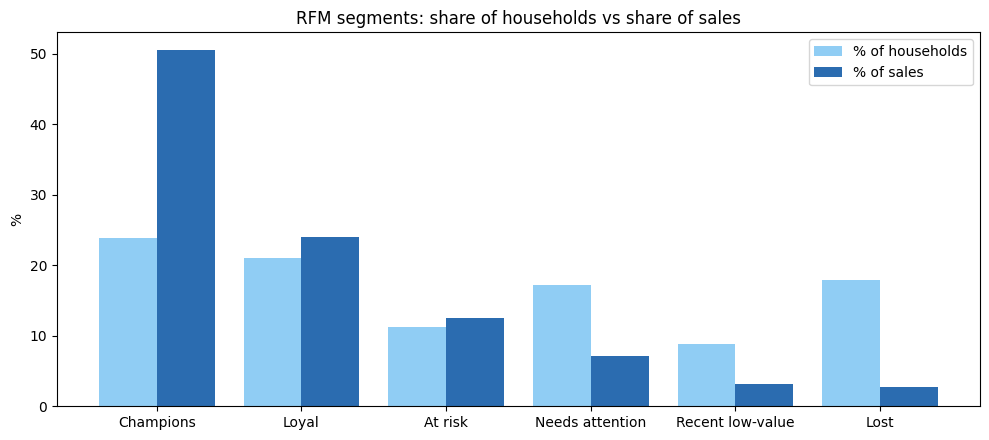

,segment,households,households_pct,sales_pct,avg_spend_per_week,avg_trips_per_week,avg_recency_days,avg_basket_value,avg_departments,private_share_pct,promo_share_pct
0,Champions,594,23.8,50.5,68.20,2.24,1.3,36.24,12.7,21.7,47.1
1,Loyal,523,21.0,24.0,37.00,1.26,4.4,34.23,11.4,22.5,47.0
2,At risk,280,11.2,12.5,36.48,1.17,33.1,35.79,11.3,22.8,47.8
3,Needs attention,428,17.2,7.1,13.74,0.50,27.6,31.10,9.5,22.6,47.6
4,Recent low-value,222,8.9,3.1,11.79,0.49,1.8,26.62,8.9,22.6,46.5
5,Lost,446,17.9,2.7,5.12,0.22,87.2,27.29,7.3,23.0,45.8


In [5]:
seg = q("""
SELECT r.segment,
       COUNT(*) AS households,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS households_pct,
       ROUND(100 * SUM(h.spend) / SUM(SUM(h.spend)) OVER (), 1) AS sales_pct,
       ROUND(AVG(h.spend_per_week), 2) AS avg_spend_per_week,
       ROUND(AVG(h.baskets_per_week), 2) AS avg_trips_per_week,
       ROUND(AVG(h.recency_days), 1) AS avg_recency_days,
       ROUND(AVG(h.avg_basket_value), 2) AS avg_basket_value,
       ROUND(AVG(h.departments), 1) AS avg_departments,
       ROUND(100 * AVG(h.private_share), 1) AS private_share_pct,
       ROUND(100 * AVG(h.promo_share), 1) AS promo_share_pct
FROM rfm r
JOIN hh_features h ON h.household_key = r.household_key
GROUP BY r.segment
ORDER BY sales_pct DESC
""")
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(seg))
ax.bar(x - 0.2, seg.households_pct, 0.4, color='#90cdf4', label='% of households')
ax.bar(x + 0.2, seg.sales_pct, 0.4, color='#2b6cb0', label='% of sales')
ax.set_xticks(x, seg.segment)
ax.set(ylabel='%', title='RFM segments: share of households vs share of sales')
ax.legend()
plt.tight_layout(); plt.savefig(FIG/'04_rfm_segments.png', dpi=150); plt.show()
seg

## 4. K-means clustering
RFM only looks at three dimensions. Clustering on all seven features checks whether there are behaviour-based groups, such as promotion hunters or private label shoppers, that RFM mixes together.

Choices:
- **Log transform** first, because spend, frequency and recency are heavily right-skewed and k-means is driven by distances, so a few extreme households would otherwise dominate.
- **Standardise** so every feature has equal weight regardless of its units.
- **Choose k by silhouette score** over 3 to 8 clusters. k = 2 is left out because it almost always just splits heavy from light shoppers, which RFM already does.

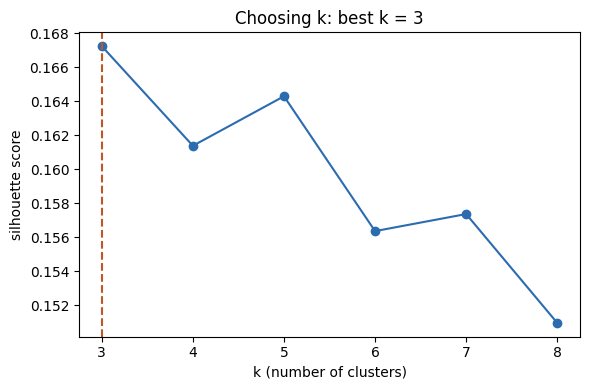

,silhouette
3,0.167
4,0.161
5,0.164
6,0.156
7,0.157
8,0.151


In [6]:
feats = ['recency_days', 'baskets_per_week', 'spend_per_week', 'avg_basket_value', 'departments', 'private_share', 'promo_share']
X = q("SELECT * FROM hh_features").set_index('household_key')
Z = StandardScaler().fit_transform(np.log1p(X[feats]))
sil = {k: silhouette_score(Z, KMeans(k, n_init=10, random_state=42).fit_predict(Z)) for k in range(3, 9)}
best_k = max(sil, key=sil.get)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(sil), list(sil.values()), marker='o', color='#2b6cb0')
ax.axvline(best_k, color='#c05621', ls='--')
ax.set(xlabel='k (number of clusters)', ylabel='silhouette score', title=f'Choosing k: best k = {best_k}')
plt.tight_layout(); plt.savefig(FIG/'04_kmeans_silhouette.png', dpi=150); plt.show()
pd.Series(sil, name='silhouette').round(3)

In [7]:
X['cluster'] = KMeans(best_k, n_init=10, random_state=42).fit_predict(Z)
X.groupby('cluster')[feats].median().round(2).assign(households=X.cluster.value_counts().sort_index())

,recency_days,baskets_per_week,spend_per_week,avg_basket_value,departments,private_share,promo_share,households
cluster,,,,,,,,
0,2.0,1.51,50.43,32.79,13.0,0.18,0.44,966
1,38.0,0.24,4.39,17.35,7.0,0.19,0.40,539
2,9.0,0.65,18.13,28.18,10.0,0.25,0.52,988


Cluster profiles use medians because the features are skewed. Silhouette scores for customer data are usually modest (often 0.15 to 0.35). A score in that range means the clusters overlap: they are useful groupings for targeting, not sharply separated customer types.

### How do clusters line up with RFM segments?
Each row shows how an RFM segment spreads across clusters. A segment that splits across several clusters contains households with different behaviour, which RFM alone would treat the same.

In [8]:
pd.crosstab(q("SELECT household_key, segment FROM rfm").set_index('household_key').segment, X.cluster, normalize='index').mul(100).round(1)

cluster,0,1,2
segment,,,
At risk,32.9,2.5,64.6
Champions,93.8,0.0,6.2
Lost,0.0,80.0,20.0
Loyal,55.6,1.0,43.4
Needs attention,1.9,28.5,69.6
Recent low-value,8.1,21.6,70.3


## 5. Demographic profile of segments
Only the 801 profiled households, who spend about 3x more than the rest (notebook 02), so this describes engaged customers. Income is grouped into 3 bands, and the three light segments (Needs attention, Recent low-value, Lost) are merged into one "Light" group, because very few profiled households fall into them.

A chi-square test checks whether segment membership depends on income band. Its assumption is that every expected count is at least 5. Without the merge the smallest expected count is 3.7, which breaks that assumption, so the merged table is tested and its minimum expected count is printed as a check. Cramér's V measures the strength of the association (0 = none, 1 = perfect).

In [9]:
demo = q("""
SELECT CASE WHEN r.segment IN ('Needs attention', 'Recent low-value', 'Lost') THEN 'Light (merged)' ELSE r.segment END AS segment,
       CASE WHEN h.income IN ('Under 15K', '15-24K', '25-34K') THEN '1: under 35K'
            WHEN h.income IN ('35-49K', '50-74K') THEN '2: 35-74K'
            ELSE '3: 75K+' END AS income_band
FROM rfm r
JOIN dim_household h ON h.household_key = r.household_key
WHERE h.has_demo
""")
ct = pd.crosstab(demo.segment, demo.income_band)
chi2, p, dof, expected = chi2_contingency(ct)
print(f"chi2 = {chi2:.1f}, dof = {dof}, p = {p:.3g}, Cramer's V = {np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1))):.3f}, min expected count = {expected.min():.1f}")
ct.div(ct.sum(axis=0), axis=1).mul(100).round(1)

chi2 = 7.0, dof = 6, p = 0.32, Cramer's V = 0.066, min expected count = 10.9


income_band,1: under 35K,2: 35-74K,3: 75K+
segment,,,
At risk,18.9,15.4,14.2
Champions,44.3,49.5,50.2
Light (merged),2.8,5.5,6.7
Loyal,34.0,29.7,28.9


The table shows, for each income band, the percentage of its households in each segment (columns sum to 100).

## 6. Save segments
One row per household with its RFM scores, segment and cluster, for the campaign analysis and the Power BI dashboard.

In [10]:
con.register('clusters', X[['cluster']].reset_index())
con.execute(f"""
COPY (
  SELECT r.household_key, r.r, r.f, r.m, r.segment, c.cluster,
         h.spend_per_week, h.baskets_per_week, h.recency_days, h.avg_basket_value, h.departments, h.private_share, h.promo_share
  FROM rfm r
  JOIN clusters c ON c.household_key = r.household_key
  JOIN hh_features h ON h.household_key = r.household_key
) TO '{DATA}/household_segments.parquet' (FORMAT PARQUET)
""")
q(f"SELECT COUNT(*) AS households, COUNT(DISTINCT segment) AS segments, COUNT(DISTINCT cluster) AS clusters FROM '{DATA}/household_segments.parquet'")

,households,segments,clusters
0,2493,6,3


## Findings

1. **Half of sales come from under a quarter of households.** Champions are 23.8% of households but 50.5% of sales. They shop 2.24 times a week, spend $68.20 a week, and last shopped 1.3 days ago on average. Together with Loyal households (21.0% of households, 24.0% of sales), 45% of households bring 74.5% of sales.
2. **At risk is the segment that needs action now.** 280 households (11.2%) spend $36.48 a week, almost exactly what Loyal households spend, but have not shopped for 33 days on average. That is well past the 23-day gap that notebook 03 found only 5% of visits exceed. Together they are worth about $10,200 a week, roughly 13% of weekly merchandise sales.
3. **Lost households are not worth heavy spending.** 446 households (17.9%) bring only 2.7% of sales, spend $5.12 a week and have been away for 87 days on average.
4. **Light but active households are the growth pool.** Needs attention (17.2% of households) and Recent low-value (8.9%) still shop, but have the smallest baskets ($26.62 to $31.10) and buy from fewer departments (8.9 to 9.5, against 12.7 for Champions).
5. **Value comes from frequency and breadth, not from deal-seeking.** Private label share (21.7 to 23.0%) and promotion share (45.8 to 47.8%) are almost identical in every segment. What separates Champions from Lost households is how often they come and how many departments they buy from.
6. **K-means confirms RFM rather than adding new segments.** The best silhouette score is 0.167 at k = 3, which means weak separation. The three clusters are heavy frequent shoppers (971 households, $50.29 a week), middle shoppers (977, $18.18) and light lapsed shoppers (545, $4.41). 93.8% of Champions fall in the heavy cluster and 80.3% of Lost in the light one. There is no separate promotion-hunter or private-label group. RFM is simpler to explain and act on, so it is the segmentation used in notebooks 07 and 08.
7. **Income does not predict segment.** Among profiled households, the merged chi-square test is not significant (chi2 = 7.0, df = 6, p = 0.32, Cramér's V = 0.07, minimum expected count 10.9). About 44 to 50% of profiled households in every income band are Champions, against 23.8% overall, which again shows that profiled households are mostly heavy shoppers.

## Recommendations
1. **Run a win-back programme for the 280 At risk households first.** They spend like Loyal customers but have gone quiet for over a month, and they carry about $10,200 of weekly sales. A personalised offer based on their past baskets is the highest-value retention action available.
2. **Protect Champions with recognition, not discounts.** They do not buy more on promotion than anyone else, so blanket discounts would mostly give away margin. Service benefits, early access or a loyalty tier fit their behaviour better.
3. **Grow light households by widening their shop.** The difference between segments is breadth of shop and visit frequency. Cross-category offers (for example produce or deli offers for households that only buy grocery) target exactly that gap.
4. **Keep spending on Lost households low.** At $5 a week and almost three months away, a low-cost automated reminder is enough.
5. **Target on behaviour, not income.** Segment membership does not depend on income, so behaviour-based segments are the right basis for campaigns. Demographic targeting would also only reach the 32% of households that are profiled.